# KnowQA data showcase

What Study 2 has collected so far, and how the L1-trained correctness model transfers to it.

**Two halves.** First a description of the collected data — cohort, correctness, pace, confidence —
split by knowledge regime. Then the L1 model, trained on all 19,436 Study 1 trials and applied to
every KnowQA trial: how well it transfers, what errors it makes, what probabilities it assigns,
and how it compares against the participant's own confidence rating.

All computation lives in
`src/predictive_modeling/answer_correctness/knowledge_regimes_analysis/descriptives.py`.
This notebook loads, calls and displays — nothing is defined here, so every number is reproducible
without opening it. The confidence correlations reuse the existing `confidence_correlation` module.

**Run from the repo root.** Every path resolves through `data_paths.PROJECT_ROOT`, so unlike the
older notebooks this one does not assume `cwd == notebooks/`.

In [1]:
%matplotlib inline

# descriptives.py is edited while this notebook is open, and a plain `import` caches
# the module for the life of the kernel — so a function added after the first import
# shows up as AttributeError until you restart. autoreload re-imports it on every cell.
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt

import src.predictive_modeling.answer_correctness.knowledge_regimes_analysis.descriptives as D
from src.predictive_modeling.answer_correctness.knowledge_regimes_analysis import (
    confidence_correlation as CC,
)
from src.viz.plot_output import save_output

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 50)

# Persist through plot_output.save_output into
# reports/correctness_prediction/knowledge_regimes/ (T4.0: a PNG is not a record).
SAVE = False
ANALYSIS = "correctness_prediction/knowledge_regimes"

def keep(df, name):
    """Show a table and, when SAVE, persist it. Returns None so the cell renders once."""
    display(df)
    if SAVE:
        save_output(None, analysis=ANALYSIS, plot=name,
                    tables={"data": df}, save=SAVE)

def keep_fig(fig, name):
    """Show a figure and, when SAVE, persist it. Accepts the (fig, axes) tuple the
    confidence_correlation plotters return as well as a bare Figure."""
    if isinstance(fig, tuple):
        fig = fig[0]
    if SAVE:
        # numbers for these come from the companion keep() call above
        save_output(fig, analysis=ANALYSIS, plot=name, tables={}, save=SAVE)
    return fig

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## 1. What has been collected

`load_showcase_frame` reads the model-ready KnowQA features and re-attaches `regime`,
`session_id` and `confidence_rating` from the cleaned IA report — the feature builder drops
them. The merge asserts that every trial picks up a regime, because an unmatched trial would
drop silently out of every per-regime group-by while still counting in the pooled totals.

Practice trials are already excluded upstream: the IA report holds 924 trials, 54 of them
practice, and the 870 non-practice trials match the feature table exactly in both directions.

In [2]:
df = D.load_showcase_frame()

KnowQA showcase frame: 870 trials x 199 columns
  participants : 6
  sessions     : 18
  regimes      : {'no knowledge': 300, 'full knowledge': 294, 'partial knowledge': 276}


In [3]:
keep(D.cohort_summary(df), "cohort_summary")

,participant_id,sessions,trials,no knowledge,partial knowledge,full knowledge
0,4000,3,145,50,46,49
1,4001,3,145,50,46,49
2,4002,3,145,50,46,49
3,4003,3,145,50,46,49
4,4004,3,145,50,46,49
5,4005,3,145,50,46,49


## 2. Correctness

The manipulation check. `no knowledge` trials had no context to answer from, so their accuracy
is the **empirical guess rate** — the quantity the paper's error analysis needs, and the one
place we learn how far above 1-in-4 a "guess" actually lands.

In [4]:
keep(D.correctness_by_regime(df).round(4), "correctness_by_regime")

,regime,n,n_correct,accuracy,ci_low,ci_high
0,all,870,633,0.7276,0.6971,0.7561
1,no knowledge,300,126,0.4200,0.3655,0.4765
2,partial knowledge,276,223,0.8080,0.7574,0.8501
3,full knowledge,294,284,0.9660,0.9385,0.9814


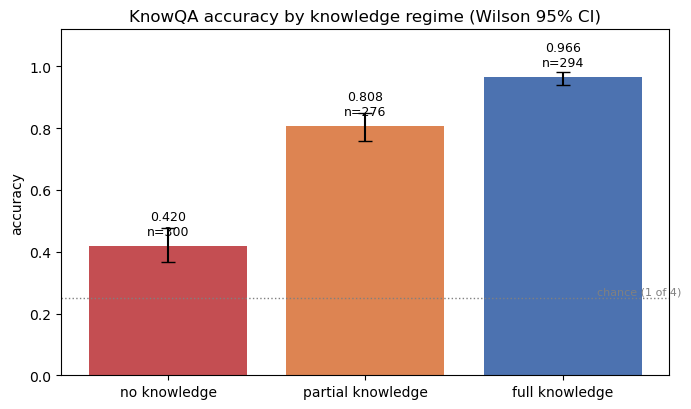

In [5]:
keep_fig(D.plot_accuracy_by_regime(D.correctness_by_regime(df)), "accuracy_by_regime");

In [6]:
# Per participant, to see whether the regime effect is population-wide or driven by a few people.
keep(
    D.correctness_by_regime(df, by=["participant_id"])
     .pivot(index="participant_id", columns="regime", values="accuracy")
     .reindex(columns=["all", *D.REGIME_ORDER])
     .round(3),
    "correctness_by_participant_regime",
)

regime,all,no knowledge,partial knowledge,full knowledge
participant_id,,,,
4000,0.779,0.50,0.848,1.000
4001,0.772,0.50,0.848,0.980
4002,0.745,0.42,0.848,0.980
4003,0.724,0.38,0.848,0.959
4004,0.676,0.32,0.783,0.939
4005,0.669,0.40,0.674,0.939


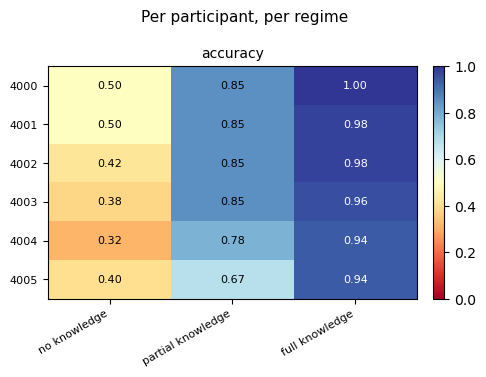

In [7]:
keep_fig(D.plot_participant_regime_heatmap(df, measures=("accuracy",), figsize=(5, 3.8)),
         "accuracy_participant_regime_heatmap");

## 3. Pace

KnowQA has no paragraph screen, so every measure here is about the answer screen: the question
plus the four options. `total_answering_RT` is answers-shown to confirm-press;
`total_answering_RT_normalized` divides it by the number of words that actually received an
interest area, so it reads as milliseconds per word on screen.

In [8]:
keep(
    D.reading_speed_by_regime(df)[["regime", "measure", "label", "n", "mean", "std", "median"]].round(2),
    "pace_by_regime",
)

,regime,measure,label,n,mean,std,median
0,all,total_answering_RT,total answering time (ms),870,11471.02,9650.73,8884.00
1,all,total_answering_RT_normalized,ms per word on screen,870,302.14,254.57,230.11
2,all,RT_normalized_question,"ms per word, question",870,128.31,240.10,27.73
3,all,RT_normalized_correct,"ms per word, correct answer",870,510.93,534.25,374.52
4,all,RT_normalized_wrong_mean,"ms per word, wrong answers (mean)",870,368.83,366.16,273.22
5,all,seq_len,area transitions in the trial,870,8.59,6.15,7.00
6,all,ANSWER_PRESS_NUMBER,selection presses before confirming,870,1.45,1.21,1.00
7,no knowledge,total_answering_RT,total answering time (ms),300,14969.32,10143.14,12527.00
8,no knowledge,total_answering_RT_normalized,ms per word on screen,300,393.49,256.29,327.41
9,no knowledge,RT_normalized_question,"ms per word, question",300,229.49,314.13,95.30


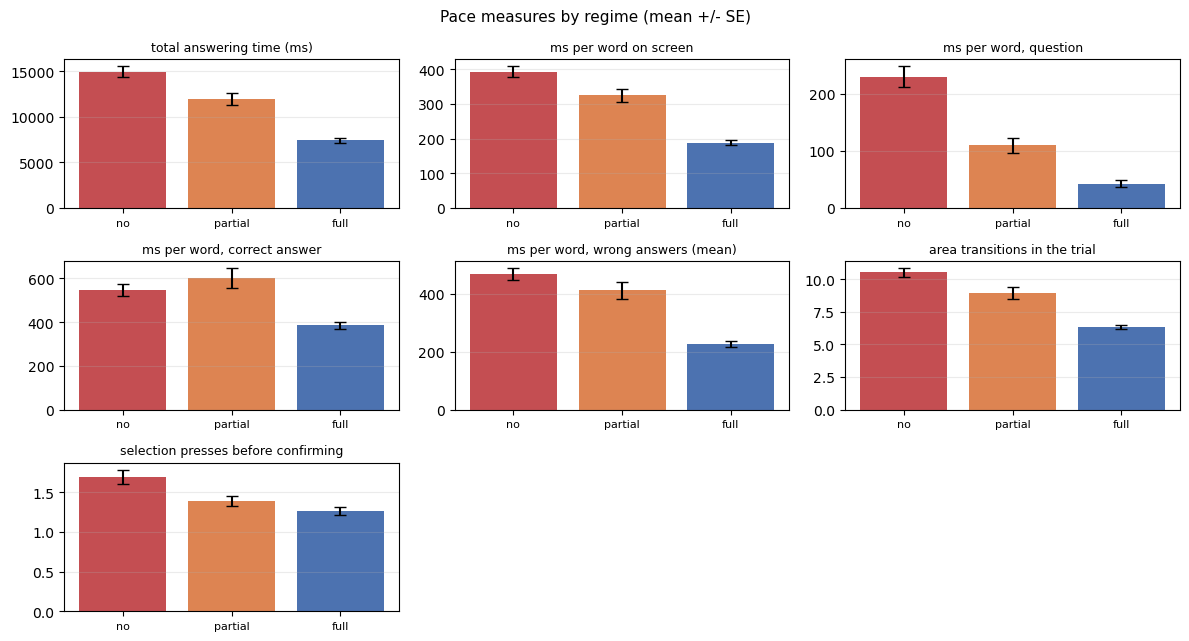

In [9]:
# Every pace measure at once — means with SE whiskers, one panel per measure.
keep_fig(D.plot_pace_panel(df), "pace_panel");

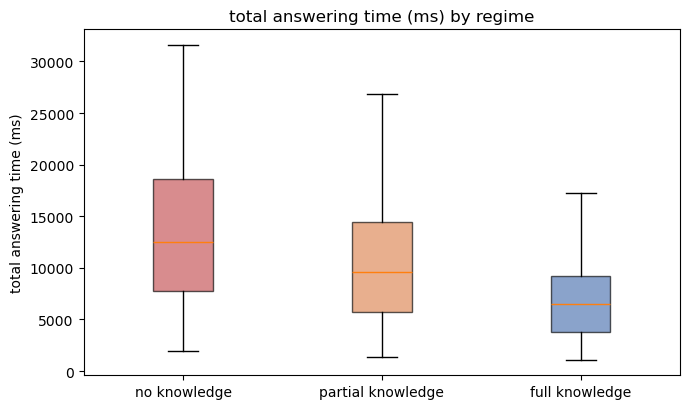

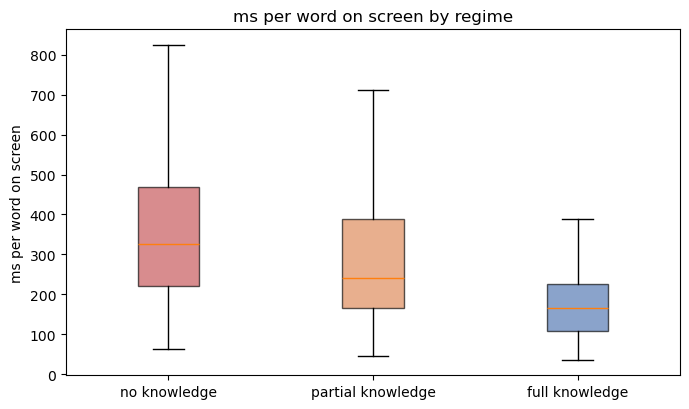

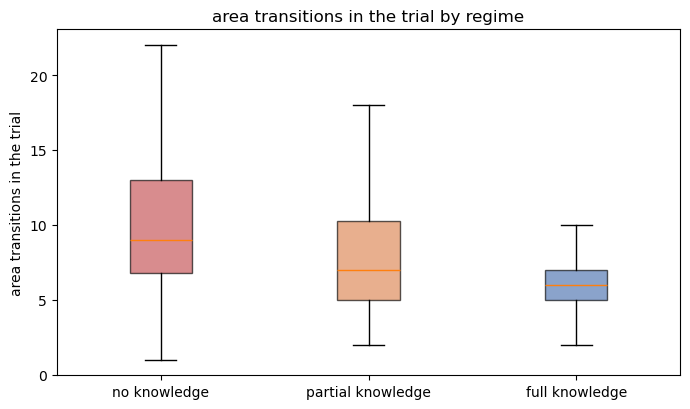

In [10]:
# Distributions behind three of those means, where the spread matters most.
for measure in ["total_answering_RT", "total_answering_RT_normalized", "seq_len"]:
    keep_fig(D.plot_pace_by_regime(df, measure), f"pace_{measure}")
plt.show()

## 4. Confidence — descriptives

Study 2's per-trial 1–5 self-report, which Study 1 lacked. Split by whether the answer was
actually correct, so the gap between the two columns is the participant's own calibration.
Section 6 turns this into correlations and compares it against the model.

,regime,n,mean_confidence,n_correct,mean_confidence_correct,n_wrong,mean_confidence_wrong
0,all,870,3.437,633,3.959,237,2.042
1,no knowledge,300,1.763,126,1.873,174,1.684
2,partial knowledge,276,3.830,223,4.063,53,2.849
3,full knowledge,294,4.776,284,4.803,10,4.000


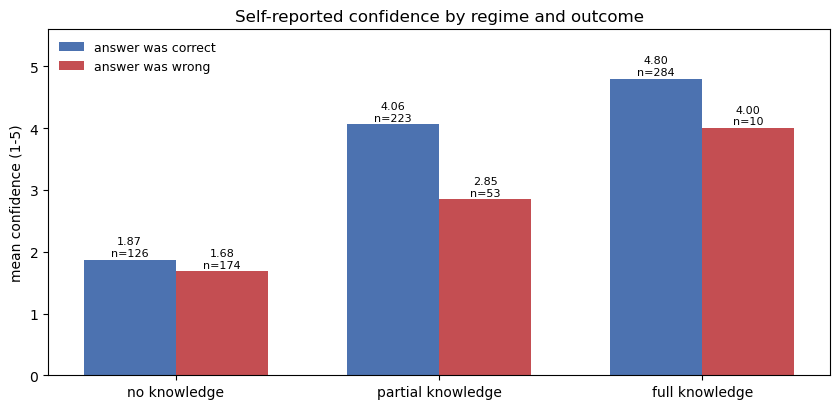

In [11]:
keep(D.confidence_by_regime(df).round(3), "confidence_by_regime")
keep_fig(D.plot_confidence_by_regime(D.confidence_by_regime(df)), "confidence_by_regime");

confidence_rating,regime,1,2,3,4,5
0,no knowledge,0.500,0.313,0.127,0.043,0.017
1,partial knowledge,0.029,0.112,0.170,0.377,0.312
2,full knowledge,0.000,0.003,0.031,0.153,0.813


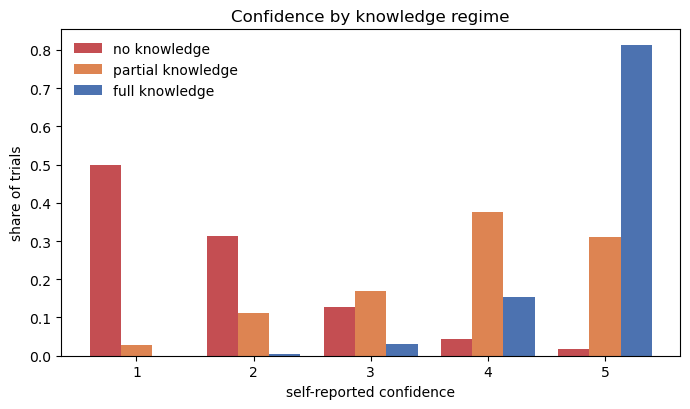

In [12]:
keep(D.confidence_distribution(df).round(3), "confidence_distribution")
keep_fig(D.plot_confidence_distribution(df), "confidence_distribution");

## 5. The L1 model on KnowQA

Fit once on all of Study 1, then applied to every KnowQA trial. The feature set is the paper's
best cross-validated one: the ten hand-picked attention features plus the two
last-fixation-before-confirm indicators. All twelve exist in KnowQA — the only Study 1 features
Study 2 cannot have are the paragraph-span family, which needs a paragraph screen.

Two things the numbers do not show on their own, both in the module docstring: the pupil
z-score is baselined per participant in L1 but per session in KnowQA, and the `StandardScaler`
is L1's, so KnowQA features are standardized against Study 1's means and SDs.

In [13]:
model = D.fit_l1_model()
df = D.attach_predictions(df, model)

fitted trial_level_log_reg on 19436 L1 trials, 12 features
  L1 base rate: 0.8407
imputed with fill_value=0.0: 10 cell(s) = 0.096% of the KnowQA feature matrix
    mean_max_fix_pupil_size_z__correct: 10 (1.15% of trials)


### 5.1 Transfer performance and error composition

`balanced_accuracy` is the comparable number — Study 1 reports ~0.83. Note that `accuracy` and
`balanced_accuracy` diverge sharply per regime because the regimes have wildly different base
rates (0.42 to 0.97), which is the manipulation working, not a modelling problem.

**Read the accuracy bar against the dashed line in the figure.** That line is the regime's own
accuracy — the score you would get by predicting "correct" on every trial. Under
`class_weight="balanced"` the model trades majority-class accuracy for catching the minority
class, so in partial and full knowledge its raw accuracy sits *below* that baseline (by 9 and
16 points) while `specificity` holds at ~0.91 throughout: it flags roughly nine in ten wrong
answers no matter how rare they are. In full knowledge that means finding 9 of the 10 errors
among 294 trials, which an always-correct predictor misses entirely.

`FN_over_FP` is the error asymmetry the paper's error-analysis subsection is built on (~6x on
Study 1). Read the per-regime values with the raw `FP` count in view: full knowledge has one.

,regime,n,n_correct,n_wrong,accuracy,balanced_accuracy,sensitivity,specificity,TP,TN,FP,FN,FN_over_FP
0,all,870,633,237,0.783,0.822,0.736,0.907,466,215,22,167,7.591
1,no knowledge,300,126,174,0.820,0.803,0.698,0.908,88,158,16,38,2.375
2,partial knowledge,276,223,53,0.714,0.787,0.668,0.906,149,48,5,74,14.800
3,full knowledge,294,284,10,0.810,0.853,0.806,0.900,229,9,1,55,55.000


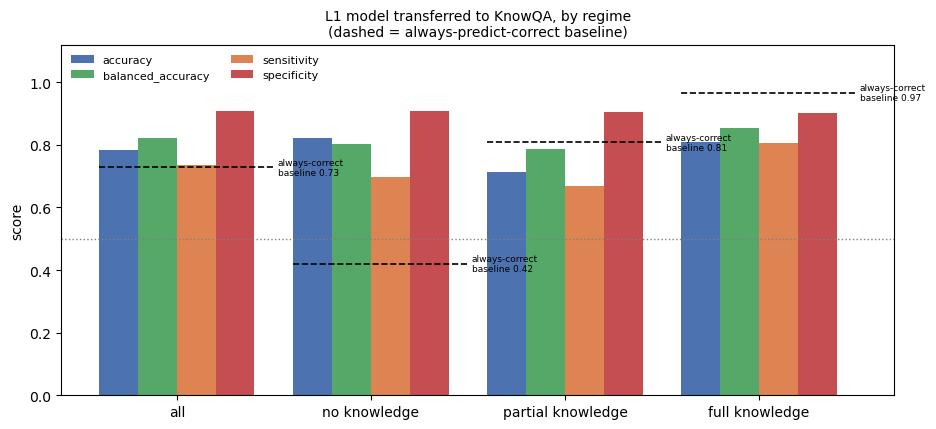

In [14]:
keep(D.prediction_metrics_by_regime(df).round(3), "transfer_metrics_by_regime")
keep_fig(D.plot_transfer_metrics(D.prediction_metrics_by_regime(df)), "transfer_metrics");

### 5.2 Confusion matrices

One panel per regime. Shading is row-normalised — the share of each *actual* class — because
the base rates run from 0.42 to 0.97 and raw counts alone would describe the manipulation
rather than the model. Raw counts are in the annotation.

Under row normalisation the two diagonal fractions **are** specificity (top-left) and
sensitivity (bottom-right), so the panel's balanced accuracy is just their mean — printed in
each title alongside plain accuracy and the base rate, so the three are never confused.

The diagonal is what transfers; the off-diagonal is where it fails, and the two off-diagonal
cells are not symmetric in cost under the confidence reading.

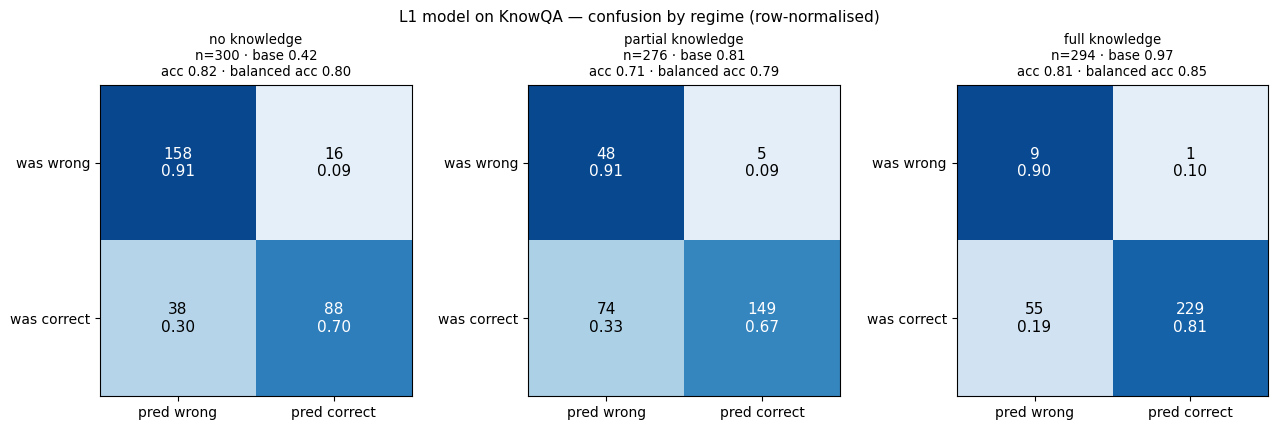

In [15]:
keep_fig(D.plot_confusion_by_regime(df), "confusion_by_regime");

### 5.3 Predicted probabilities

The paper's Study 2 prediction: high probabilities under full knowledge, low under no knowledge
— *including* on the no-knowledge trials that happened to be answered correctly, since the model
reads behaviour rather than outcome.

In the histograms the question is whether the two humps separate **within** a panel. That is the
model discriminating inside a regime, as opposed to merely inheriting that regime's base rate.

In [16]:
keep(D.probability_by_regime(df).round(3), "probability_by_regime")

,regime,n,mean_prob,median_prob,sd_prob,n_correct,mean_prob_correct,n_wrong,mean_prob_wrong
0,all,870,0.558,0.627,0.360,633,0.700,237,0.179
1,no knowledge,300,0.385,0.265,0.342,126,0.663,174,0.183
2,partial knowledge,276,0.565,0.643,0.348,223,0.660,53,0.165
3,full knowledge,294,0.729,0.885,0.301,284,0.748,10,0.182


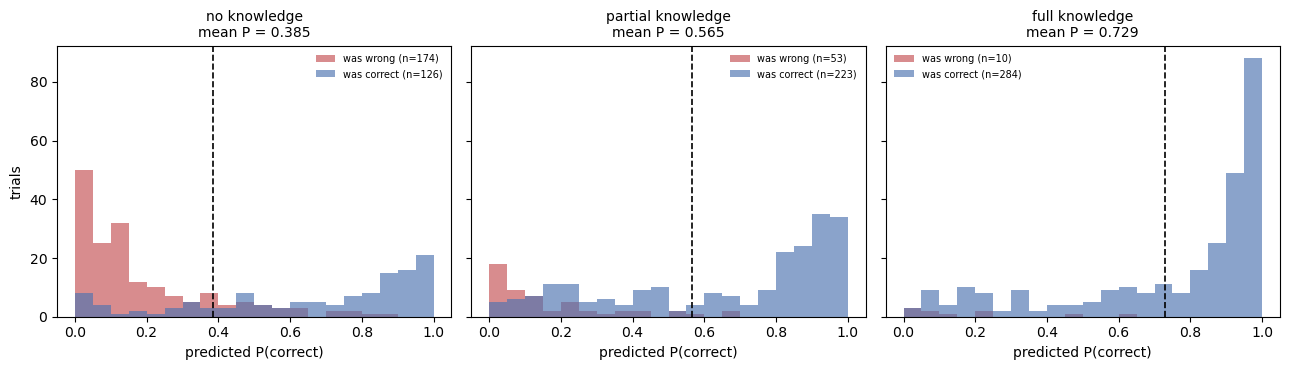

In [17]:
keep_fig(D.plot_probability_histograms(df), "probability_histograms");

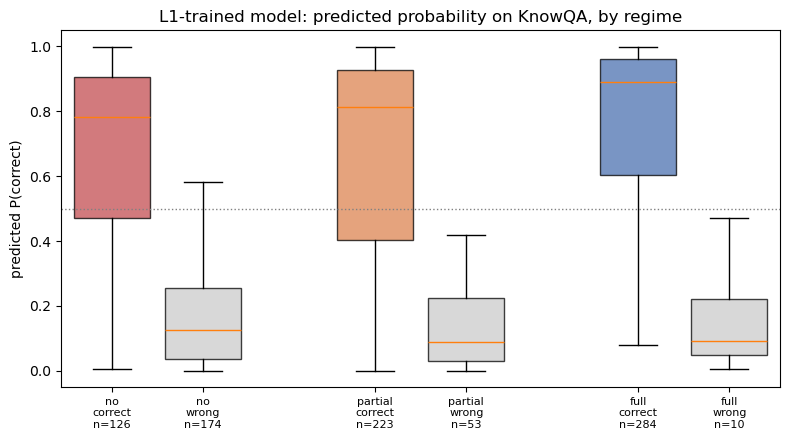

In [18]:
keep_fig(D.plot_probability_by_regime(df), "probability_by_regime_split");

## 6. Confidence vs the model

Three questions, which can disagree — the framing is `confidence_correlation`'s, and the
correlation tables below come from that module unchanged.

* **model vs confidence** — does P(correct) rise with the participant's confidence?
* **confidence vs correctness** — is the self-report calibrated at all? Without this, a null
  model-vs-confidence result is uninterpretable.
* **within participant** — confidence scales are personal, so the pooled correlation mixes a
  within-subject effect with between-subject scale use.

In [19]:
pred = D.to_prediction_frame(df)
corr_by_run = CC.correlations_by_run(pred)

keep(
    corr_by_run[
        ["run", "comparison", "n", "pearson_r", "pearson_p", "spearman_r", "spearman_p"]
    ].round(4),
    "confidence_correlations_by_run",
)

,run,comparison,n,pearson_r,pearson_p,spearman_r,spearman_p
0,all,pred_prob ~ confidence,870,0.4330,0.0000,0.4330,0.0000
1,all,is_correct ~ confidence,870,0.5527,0.0000,0.5464,0.0000
2,no knowledge,pred_prob ~ confidence,300,0.0927,0.1092,0.0726,0.2098
3,no knowledge,is_correct ~ confidence,300,0.0987,0.0879,0.1158,0.0451
4,partial knowledge,pred_prob ~ confidence,276,0.3583,0.0000,0.3185,0.0000
5,partial knowledge,is_correct ~ confidence,276,0.4433,0.0000,0.4349,0.0000
6,full knowledge,pred_prob ~ confidence,294,0.1812,0.0018,0.1446,0.0131
7,full knowledge,is_correct ~ confidence,294,0.2878,0.0000,0.2539,0.0000


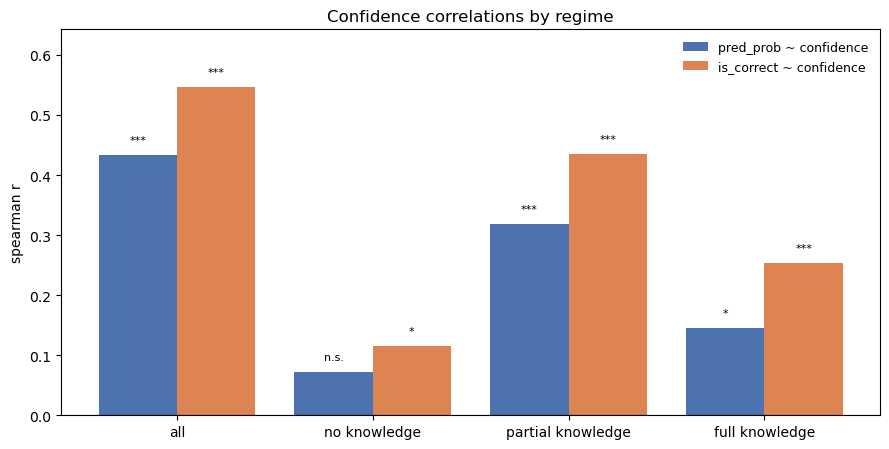

In [20]:
# Stars are on the correlation itself; the two bars in a cluster must be read together.
keep_fig(D.plot_correlations_by_run(corr_by_run), "confidence_correlations_by_run");

### 6.1 Within participant

Confidence scales are personal — one participant's "4" is another's "2" — so the pooled
correlations above mix a within-subject effect with between-subject scale use. These are the
same correlations computed inside each person.

In [21]:
corr_model = CC.correlations_by_participant(pred, run="all")
# Same call, but correlating confidence against the actual outcome instead of the model.
corr_correct = CC.correlations_by_participant(pred, run="all", prob_col="is_correct")

keep(corr_model[["participant_id", "n", "pearson_r", "spearman_r", "spearman_p"]].round(3),
     "confidence_corr_by_participant_model")
keep(corr_correct[["participant_id", "n", "pearson_r", "spearman_r", "spearman_p"]].round(3),
     "confidence_corr_by_participant_correctness")

,participant_id,n,pearson_r,spearman_r,spearman_p
0,4000,145,0.574,0.528,0.0
1,4001,145,0.338,0.311,0.0
2,4002,145,0.289,0.307,0.0
3,4003,145,0.489,0.523,0.0
4,4004,145,0.595,0.608,0.0
5,4005,145,0.463,0.497,0.0


,participant_id,n,pearson_r,spearman_r,spearman_p
0,4000,145,0.611,0.589,0.0
1,4001,145,0.528,0.513,0.0
2,4002,145,0.519,0.526,0.0
3,4003,145,0.596,0.592,0.0
4,4004,145,0.582,0.583,0.0
5,4005,145,0.549,0.552,0.0


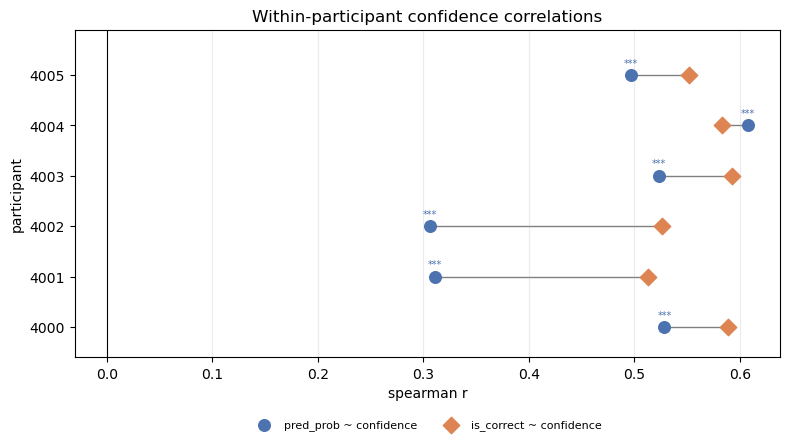

In [22]:
keep_fig(D.plot_participant_correlation_forest(corr_model, corr_correct),
         "confidence_corr_forest");

### 6.2 Behaviour at each confidence level

Does P(correct) climb with the rating, and does actual accuracy climb with it too? The grey
dashed line in the first figure is the pooled *actual* accuracy at each level — the curve the
model would have to follow to be tracking what the participants are reporting. The boxplots
show the spread behind each of those means, and the scatter is every trial.

In [23]:
level_df = CC.summarize_by_confidence_level(pred)
keep(level_df.round(3), "by_confidence_level")

,run,confidence_rating,n,mean_pred_prob,median_pred_prob,std_pred_prob,accuracy
0,all,1,158,0.342,0.187,0.325,0.361
1,all,2,126,0.402,0.317,0.361,0.500
2,all,3,94,0.414,0.331,0.334,0.543
3,all,4,162,0.642,0.805,0.340,0.864
4,all,5,330,0.721,0.867,0.294,0.976
5,no knowledge,1,150,0.351,0.205,0.328,0.353
6,no knowledge,2,94,0.418,0.332,0.357,0.511
7,no knowledge,3,38,0.386,0.280,0.330,0.421
8,no knowledge,4,13,0.499,0.453,0.420,0.462
9,no knowledge,5,5,0.451,0.578,0.366,0.600


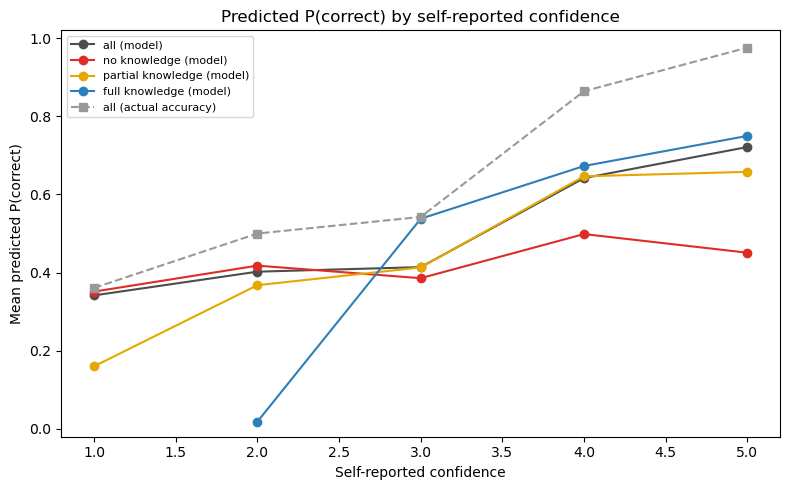

In [24]:
keep_fig(CC.plot_prob_by_confidence_level(level_df), "prob_by_confidence_level");

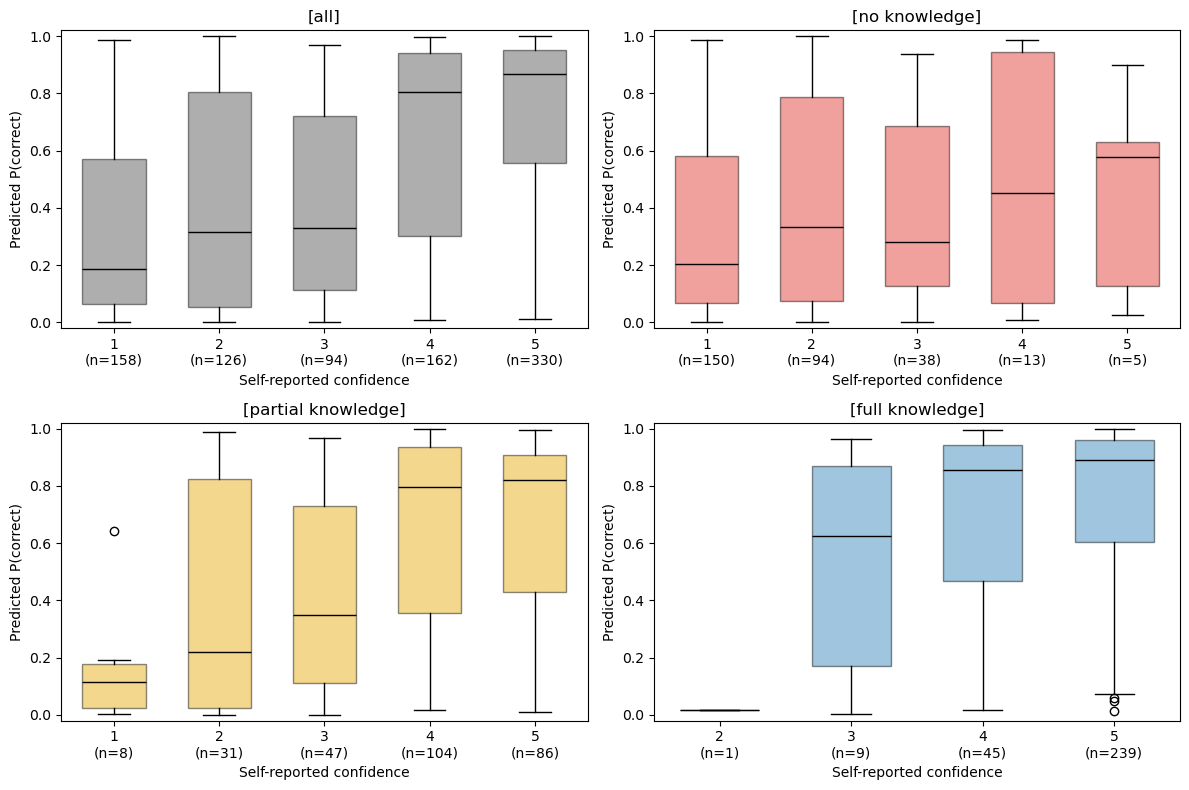

In [25]:
keep_fig(CC.plot_prob_boxplot_by_confidence(pred), "prob_boxplot_by_confidence");

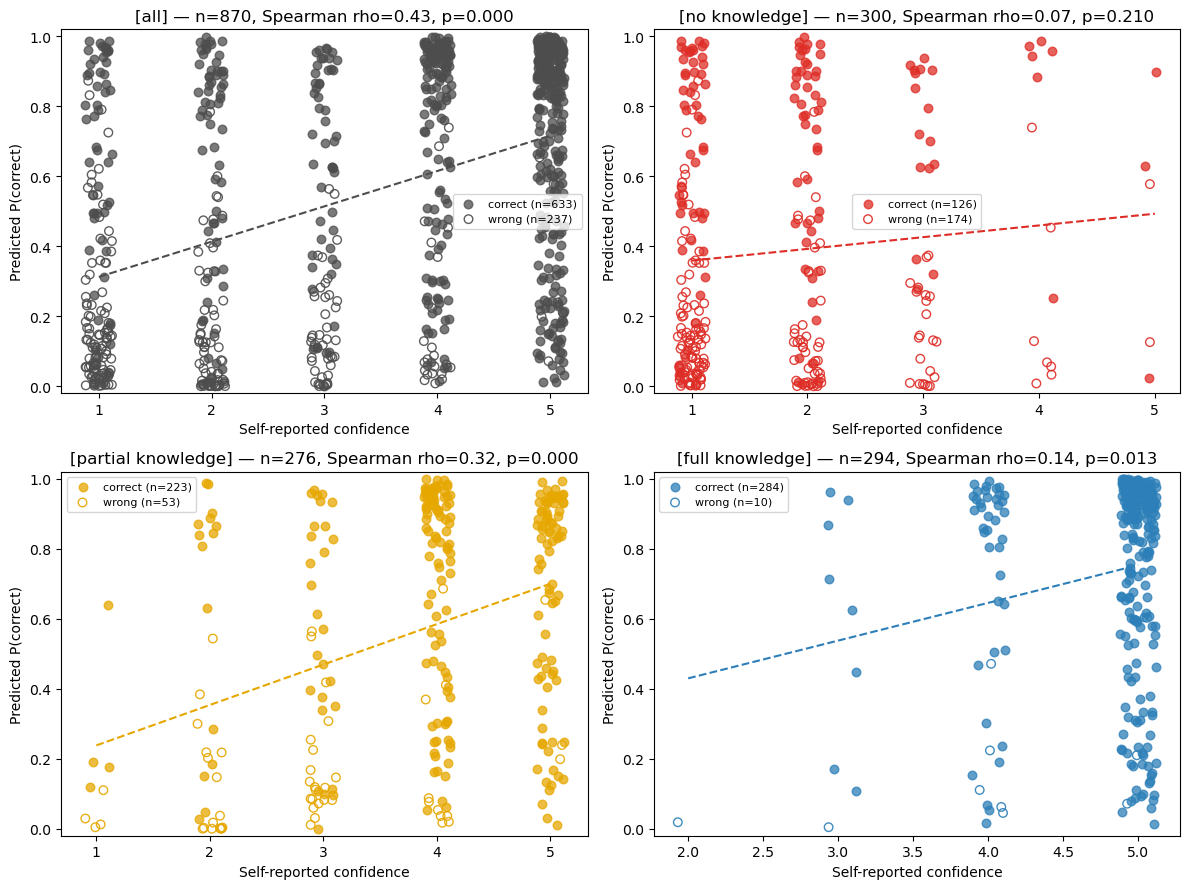

In [26]:
keep_fig(CC.plot_confidence_vs_prob_scatter(pred), "confidence_vs_prob_scatter");

### 6.3 Which discriminates better — the model or the self-report?

The paper's claim is that P(correct) can stand in for an unreliable confidence rating. That is a
claim about **discrimination**, so both are scored the same way: AUC for predicting
`is_correct`, on exactly the same trials.

`auc_combined` ranks the two and averages, so it says whether they carry the same information or
add to one another.

In [27]:
keep(D.discrimination_comparison(df).round(3), "discrimination_model_vs_confidence")

,regime,n,n_correct,auc_model,auc_confidence,auc_combined,model_minus_confidence
0,all,870,633,0.905,0.841,0.940,0.063
1,no knowledge,300,126,0.878,0.562,0.812,0.316
2,partial knowledge,276,223,0.900,0.804,0.917,0.096
3,full knowledge,294,284,0.926,0.774,0.926,0.152


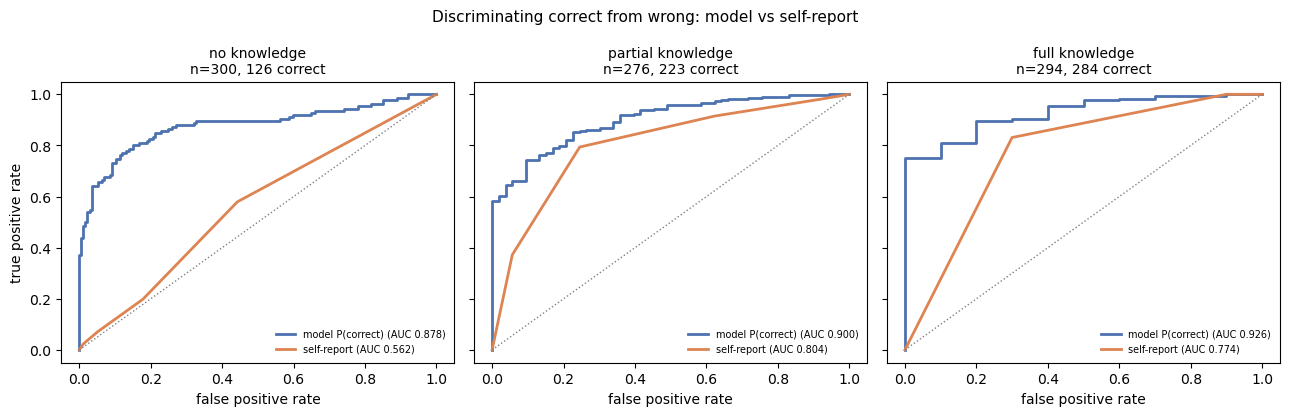

In [28]:
# The AUC table says which is better; the curves say where the difference comes from.
keep_fig(D.plot_discrimination_roc(df), "discrimination_roc");

## 7. Per participant, per session

Six people, three sessions each. Too few to test anything, so this is for spotting *shape* —
whether someone is uniformly low or low only in one regime, whether their confidence and the
model's probability move together, and whether anything drifts across their three sittings.

`model_accuracy` is how often the predicted label matched the outcome; `mean_pred_prob` is what
the model believed on average. They answer different questions and can move in opposite
directions.

**The heatmap's model panel is balanced accuracy, not plain accuracy**, for the same reason as
in section 5.1: the first panel shows base rates running from 0.32 to 1.00 across these cells,
so plain accuracy would largely restate it. The difference is not cosmetic — participant 4002
under partial knowledge reads 0.54 on plain accuracy and 0.67 balanced, while 4004 under no
knowledge goes the other way, 0.70 down to 0.55.

Two cells to read carefully. A `-` means the participant made no errors in that regime, so
specificity and therefore balanced accuracy are undefined (4000, full knowledge). And `n_wrong`
in the table is the count balanced accuracy's specificity half rests on — in the full-knowledge
column that is **0 to 3 trials**, so those values are indicative at best. `auc_model` is NaN in
the same cells and for the same reason.

In [29]:
keep(D.participant_profile(df).round(3), "participant_profile_by_regime")

,participant_id,regime,n,n_wrong,accuracy,mean_confidence,median_RT_ms,mean_seq_len,mean_pred_prob,model_accuracy,model_balanced_accuracy,model_sensitivity,model_specificity,auc_model,auc_confidence
0,4000,full knowledge,49,0,1.000,4.898,2729.0,5.306,0.875,0.918,NaN,0.918,NaN,NaN,NaN
1,4000,no knowledge,50,25,0.500,2.120,6379.0,7.980,0.535,0.900,0.900,0.880,0.920,0.966,0.706
2,4000,partial knowledge,46,7,0.848,3.652,4231.5,7.217,0.749,0.870,0.864,0.872,0.857,0.956,0.835
3,4001,full knowledge,49,1,0.980,4.673,5395.0,5.857,0.803,0.878,0.938,0.875,1.000,0.938,0.844
4,4001,no knowledge,50,25,0.500,1.200,12432.0,10.960,0.534,0.860,0.860,0.880,0.840,0.946,0.540
5,4001,partial knowledge,46,7,0.848,3.957,9768.0,9.043,0.629,0.761,0.800,0.744,0.857,0.949,0.780
6,4002,full knowledge,49,1,0.980,4.898,8867.0,5.755,0.564,0.633,0.812,0.625,1.000,1.000,0.469
7,4002,no knowledge,50,29,0.420,1.480,12139.0,7.420,0.369,0.800,0.782,0.667,0.897,0.813,0.484
8,4002,partial knowledge,46,7,0.848,3.891,11766.0,8.087,0.470,0.543,0.672,0.487,0.857,0.795,0.800
9,4003,full knowledge,49,2,0.959,4.878,8349.0,7.020,0.669,0.776,0.883,0.766,1.000,0.957,0.957


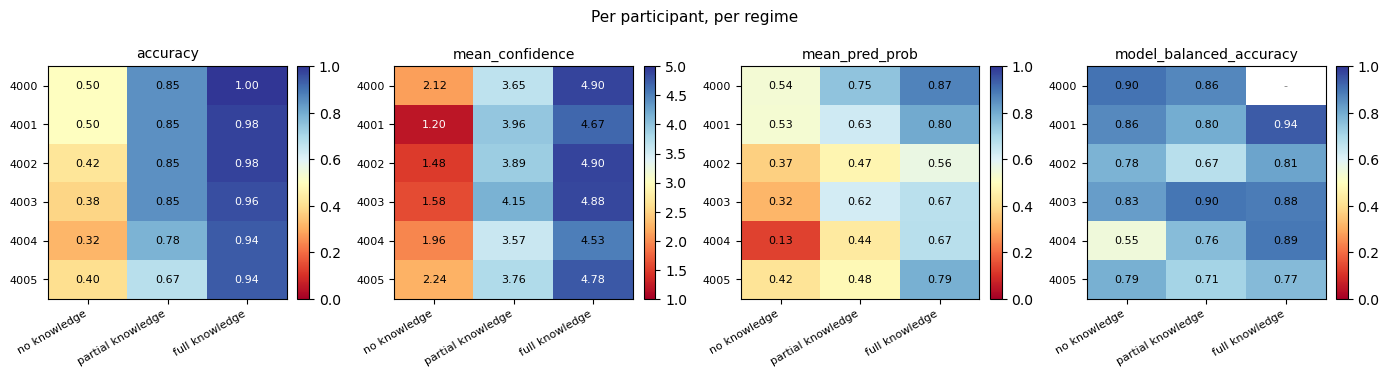

In [30]:
keep_fig(D.plot_participant_regime_heatmap(df), "participant_regime_heatmap");

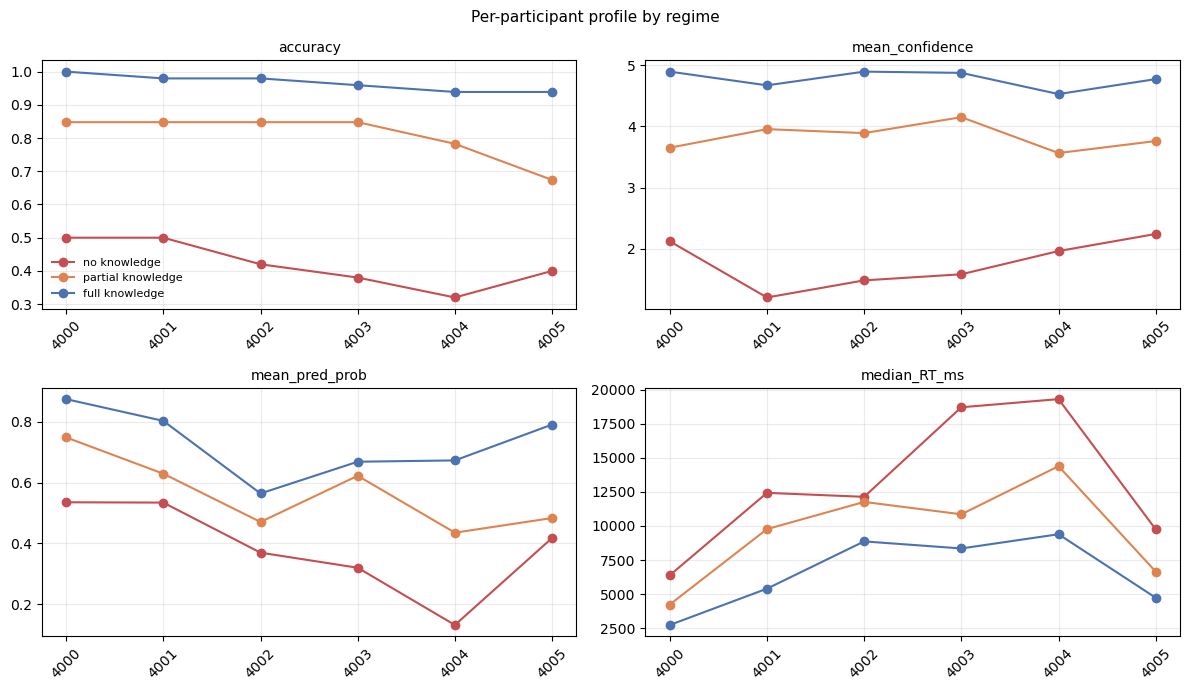

In [31]:
keep_fig(D.plot_participant_profiles(df), "participant_profiles");

### 7.1 Across the three sessions

One row per sitting, in order. Watch for practice or fatigue: a participant getting faster
across sessions is learning the interface, which is a confound for any pace measure.

In [32]:
keep(
    D.participant_profile(df, by=(D.SESSION_COL,)).round(3),
    "participant_profile_by_session",
)

,participant_id,session_id,n,n_wrong,accuracy,mean_confidence,median_RT_ms,mean_seq_len,mean_pred_prob,model_accuracy,model_balanced_accuracy,model_sensitivity,model_specificity,auc_model,auc_confidence
0,4000,4000_11,47,8,0.830,3.851,4567.0,7.745,0.731,0.894,0.886,0.897,0.875,0.942,0.902
1,4000,4000_21,50,13,0.740,3.660,3836.0,6.660,0.698,0.880,0.869,0.892,0.846,0.958,0.918
2,4000,4000_31,48,11,0.771,3.125,3545.0,6.125,0.725,0.917,0.946,0.892,1.000,0.995,0.894
3,4001,4001_12,47,9,0.809,3.447,11254.0,8.936,0.661,0.809,0.839,0.789,0.889,0.871,0.886
4,4001,4001_22,50,13,0.740,3.140,8721.0,8.280,0.629,0.880,0.894,0.865,0.923,0.967,0.862
5,4001,4001_32,48,11,0.771,3.167,6470.0,8.688,0.677,0.812,0.783,0.838,0.727,0.921,0.763
6,4002,4002_13,47,8,0.830,3.745,11094.0,6.957,0.585,0.766,0.809,0.744,0.875,0.853,0.801
7,4002,4002_23,50,11,0.780,3.220,10354.0,7.380,0.428,0.580,0.698,0.487,0.909,0.737,0.823
8,4002,4002_33,48,18,0.625,3.250,9156.5,6.854,0.393,0.646,0.694,0.500,0.889,0.798,0.817
9,4003,4003_14,47,9,0.809,3.574,12982.0,9.298,0.634,0.872,0.921,0.842,1.000,0.953,0.735


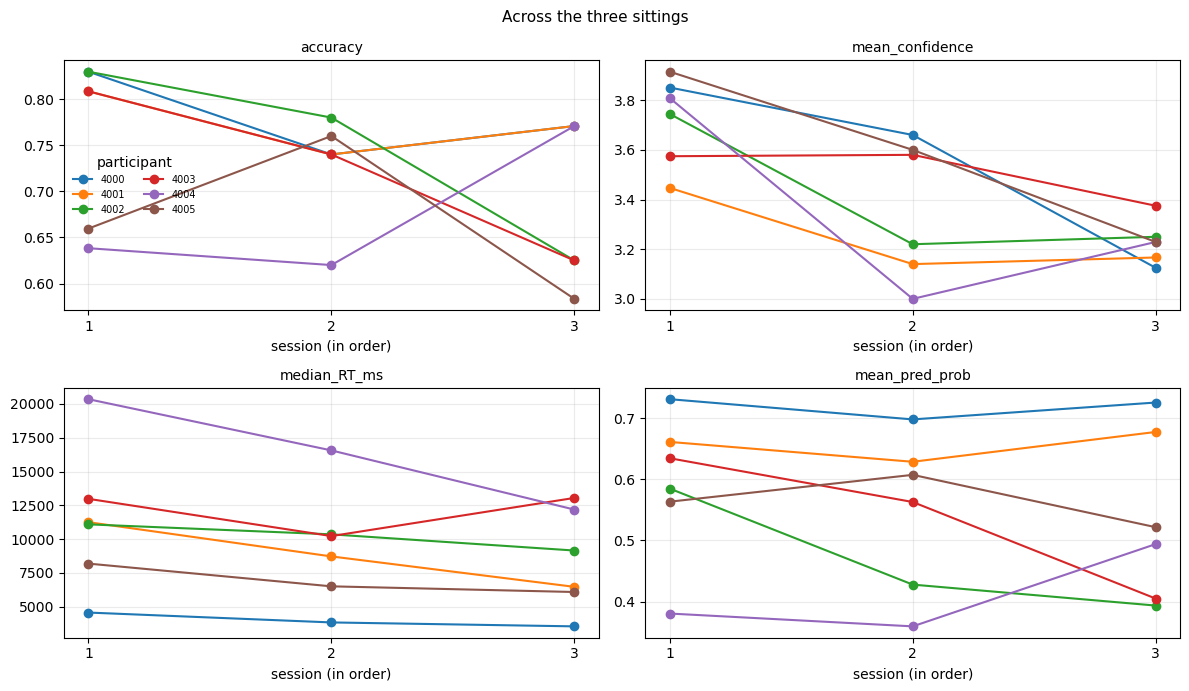

In [33]:
keep_fig(D.plot_session_trajectories(df), "session_trajectories");

### 7.2 Is the decline across sittings real?

Accuracy and confidence both fall from sitting 1 to sitting 3. Two questions: is it a real
effect, and does the model decline with it.

**Read the confound first, because it bounds everything else here.** Session order is
*perfectly* confounded with article batch — every participant took batch 1 first, batch 2
second, batch 3 third, and the three batches share no items at all. So "participants tire"
and "the later batches are harder" make identical predictions, and **adding participants will
not separate them** while the batch order stays fixed. Counterbalancing batch order in future
runs is the only thing that would.

What is available instead: every one of the 435 KnowQA items also appears in L1, where it was
answered under a completely different design with no sittings. L1's accuracy on the *same
items* is therefore an item-difficulty baseline that cannot contain a session effect, and the
tests below control for it.

In [34]:
df = D.attach_item_difficulty(D.add_session_order(df))
keep(D.session_summary(df).round(4), "session_summary")

,session,n,n_items,participant_accuracy,l1_item_acc,mean_confidence,model_balanced_accuracy,model_auc,mean_pred_prob,confidence_auc
0,1,282,141,0.7624,0.8553,3.7234,0.8534,0.9224,0.5924,0.8190
1,2,300,150,0.7300,0.8219,3.3667,0.8130,0.9052,0.5473,0.8634
2,3,288,144,0.6910,0.8059,3.2292,0.8006,0.8840,0.5361,0.8343


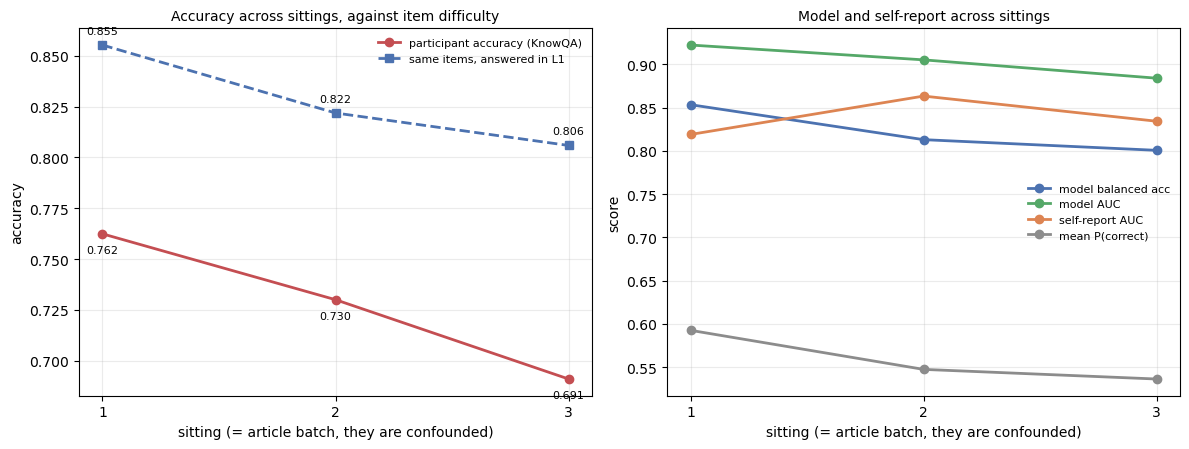

In [35]:
keep_fig(D.plot_session_trend(df), "session_trend");

Three tests, all respecting the clustering — trials are nested in six participants, so
anything treating 870 trials as independent would be badly anti-conservative.

The pair of regressions is the informative part: the first has sitting and regime, the second
adds item difficulty. Watch what the sitting coefficient does when difficulty enters.

Note the Wilcoxon's floor — with six pairs the smallest attainable p is 0.031, so that row
cannot reach 0.01 no matter how large the effect is. This is a power problem, not a null result.

In [36]:
keep(D.session_trend_tests(df).round(4), "session_trend_tests")

,test,n_units,statistic,p_value,effect,effect_is
0,"Wilcoxon, sitting 1 vs 3",6,4.0000,0.2188,-0.0714,mean accuracy difference
1,"per-participant Spearman(sitting, correct), vs 0",6,-1.5016,0.1935,-0.0669,mean within-participant rho
2,clustered logit: sitting + regime,6,0.8476,0.3598,-0.1653,log-odds per sitting (statistic = odds ratio)
3,clustered logit: sitting + regime + item diffi...,6,0.8894,0.5418,-0.1173,log-odds per sitting (statistic = odds ratio)
